# Predictive Modeling Using Machine Learning — Customer Churn Prediction

**Goal:** Predict whether a customer will churn (leave the service) based on
their account details, and compare a few classic supervised learning algorithms.

**Models compared:** Logistic Regression · Decision Tree · Random Forest

**Covers:** preprocessing, train/test split, model training, accuracy metrics,
confusion matrices, and ROC curves.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/customer_churn_data.csv")
df.head()

,CustomerID,Age,Tenure_Months,Contract,InternetService,TechSupport,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST1000,45,48,One Year,Fiber Optic,No,Bank Transfer,53.71,2575.67,0
1,CUST1001,20,69,Month-to-Month,Fiber Optic,No,Credit Card,84.18,5848.11,0
2,CUST1002,48,26,One Year,DSL,No,Credit Card,109.45,2814.32,1
3,CUST1003,49,68,Two Year,Fiber Optic,No,Electronic Check,115.43,7783.17,0
4,CUST1004,39,24,Month-to-Month,DSL,No,Bank Transfer,119.10,2833.16,1


## 1. Explore the Data

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   str    
 1   Age              1000 non-null   int64  
 2   Tenure_Months    1000 non-null   int64  
 3   Contract         1000 non-null   str    
 4   InternetService  1000 non-null   str    
 5   TechSupport      1000 non-null   str    
 6   PaymentMethod    1000 non-null   str    
 7   MonthlyCharges   1000 non-null   float64
 8   TotalCharges     1000 non-null   float64
 9   Churn            1000 non-null   int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB


In [3]:
df['Churn'].value_counts(normalize=True)

Churn
1    0.503
0    0.497
Name: proportion, dtype: float64

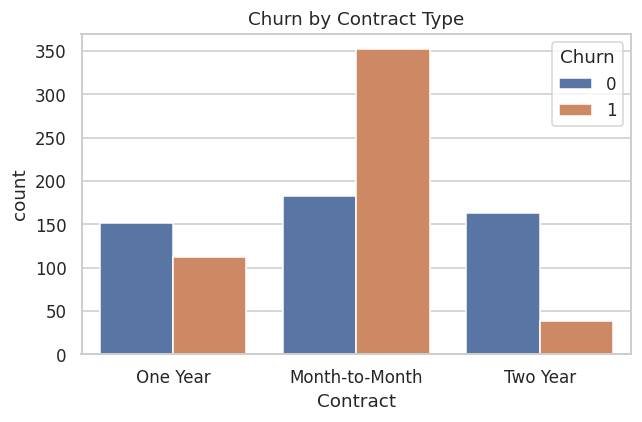

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [5]:
model_df = df.drop(columns=["CustomerID"]).copy()

categorical_cols = ["Contract", "InternetService", "TechSupport", "PaymentMethod"]
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])

model_df.head()

,Age,Tenure_Months,Contract,InternetService,TechSupport,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,45,48,1,1,0,0,53.71,2575.67,0
1,20,69,0,1,0,1,84.18,5848.11,0
2,48,26,1,0,0,1,109.45,2814.32,1
3,49,68,2,1,0,2,115.43,7783.17,0
4,39,24,0,0,0,0,119.10,2833.16,1


In [6]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 800 rows | Test: 200 rows


## 3. Train the Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8),
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.round(3)
results_df

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.71,0.722,0.693,0.707,0.835
Decision Tree,0.69,0.679,0.733,0.705,0.746
Random Forest,0.76,0.773,0.743,0.758,0.838


## 4. Confusion Matrices

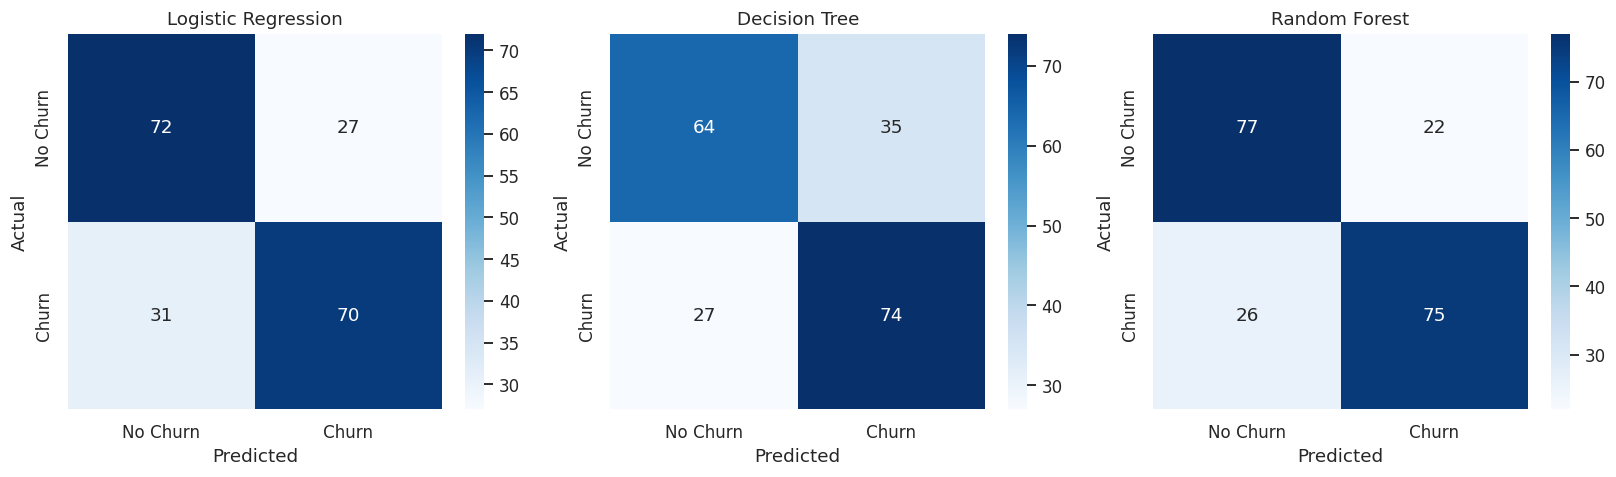

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 5. ROC Curves

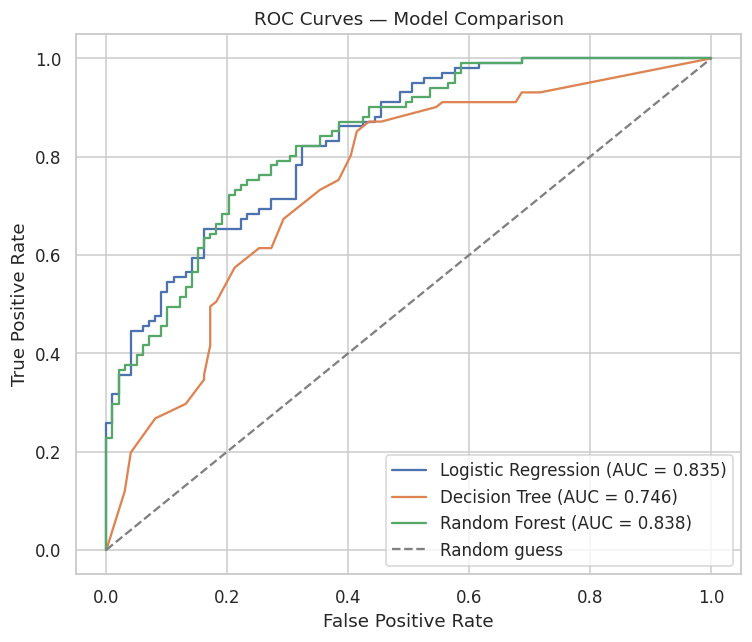

In [9]:
plt.figure(figsize=(7, 6))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]["AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance (Random Forest)

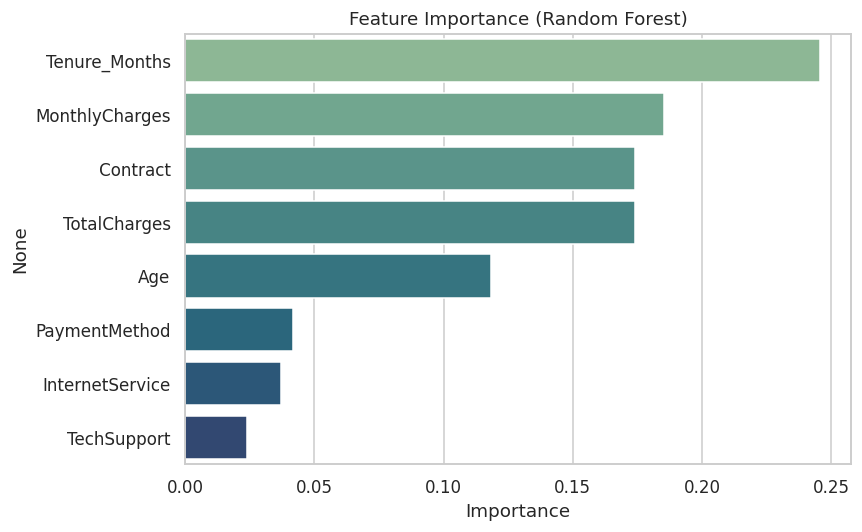

In [10]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Key Findings

- **Random Forest** performed best overall (highest F1 score and AUC).
- **Tenure (months with the company)** is the strongest predictor of churn —
  newer customers are far more likely to leave.
- All three models scored well above random-guessing baseline (AUC > 0.5),
  confirming there's real, learnable signal in the account data.
- Month-to-month contracts and lack of tech support both push churn risk up,
  matching real-world customer retention patterns.
